<a href="https://colab.research.google.com/github/rani-sikdar/Credit-Card-Fraud-Detection/blob/main/credit_card_fraud_detection_Decision_Tree_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
path="/content/creditcard.csv"

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv(path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,...,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000
mean,4257.151261,-0.299740,0.295226,0.899355,0.215736,-0.025285,0.157286,-0.026445,-0.070525,0.655244,...,-0.053715,-0.165799,-0.035174,0.025977,0.088893,0.020256,0.016150,0.001161,65.413540,0.003136
std,3198.964299,1.498341,1.283914,1.090297,1.447057,1.167218,1.325015,1.063709,1.332568,1.156618,...,0.953498,0.654858,0.488322,0.601760,0.427505,0.517409,0.403570,0.275976,194.911169,0.055915
min,0.000000,-23.066842,-25.640527,-12.389545,-4.657545,-32.092129,-7.574798,-12.968670,-23.632502,-3.878658,...,-11.468435,-8.527145,-15.144340,-2.512377,-2.577363,-1.338556,-7.976100,-3.054085,0.000000,0.000000
25%,1531.000000,-1.046362,-0.237359,0.372435,-0.687521,-0.630525,-0.655399,-0.517733,-0.199794,-0.085635,...,-0.271837,-0.581473,-0.182989,-0.340419,-0.161009,-0.363180,-0.063198,-0.019081,4.617500,0.000000
50%,3635.000000,-0.416341,0.335446,0.948695,0.223379,-0.107337,-0.148669,0.004732,0.016128,0.613170,...,-0.130344,-0.167048,-0.046107,0.089606,0.115418,-0.015260,0.007101,0.018443,15.950000,0.000000
75%,6662.000000,1.122758,0.950582,1.597949,1.131542,0.405082,0.555200,0.527353,0.307111,1.294087,...,0.044823,0.250886,0.086806,0.421015,0.361249,0.329322,0.144700,0.080563,54.910000,0.000000
max,10981.000000,1.685314,8.261750,4.101716,7.380245,11.974269,21.393069,34.303177,3.877662,10.392889,...,22.588989,4.534454,13.876221,3.200201,5.525093,3.517346,4.173387,4.860769,7712.430000,1.000000


In [6]:
df.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,-0.030253,0.014956,0.087473,0.129426,-0.020618,-0.005644,-0.107258,-0.032932,0.494365,...,-0.043831,-0.035243,0.013467,-0.005560,-0.020045,0.175298,-0.056502,-0.014495,0.001333,0.054419
V1,-0.030253,1.000000,-0.140127,-0.151728,0.067441,-0.134304,0.012231,-0.077608,0.240558,-0.159559,...,-0.119701,-0.050589,-0.150981,0.008781,0.218501,-0.027752,-0.059198,0.034514,-0.180186,-0.031975
V2,0.014956,-0.140127,1.000000,-0.041917,0.049333,0.021403,-0.035308,0.104365,-0.195950,-0.011931,...,0.114350,-0.117231,0.018352,-0.019372,-0.152644,-0.050500,0.079096,-0.090710,-0.494352,0.115137
V3,0.087473,-0.151728,-0.041917,1.000000,0.103745,-0.069638,-0.171292,0.072200,0.032600,0.131459,...,-0.010673,0.290421,-0.024169,-0.011178,-0.244406,0.105996,-0.114500,-0.106319,-0.194755,-0.291009
V4,0.129426,0.067441,0.049333,0.103745,1.000000,-0.117311,0.007611,-0.051073,0.022109,-0.114699,...,-0.018885,0.006725,0.004992,-0.055755,-0.033738,0.089277,-0.037332,0.034759,0.116691,0.169556
V5,-0.020618,-0.134304,0.021403,-0.069638,-0.117311,1.000000,0.155183,-0.119076,0.108488,-0.029746,...,-0.019786,-0.105545,0.004257,0.019242,0.001329,-0.164948,-0.050772,-0.121903,-0.428016,-0.029357
V6,-0.005644,0.012231,-0.035308,-0.171292,0.007611,0.155183,1.000000,-0.094770,-0.021637,0.012044,...,0.054949,-0.069147,-0.025110,0.040233,0.080124,-0.015998,-0.027132,-0.010161,0.223524,-0.089314
V7,-0.107258,-0.077608,0.104365,0.072200,-0.051073,-0.119076,-0.094770,1.000000,0.195267,-0.021215,...,-0.139880,0.089360,-0.052866,-0.010579,-0.100838,-0.073955,-0.067534,-0.082973,0.345714,-0.114739
V8,-0.032932,0.240558,-0.195950,0.032600,0.022109,0.108488,-0.021637,0.195267,1.000000,-0.075021,...,-0.283883,0.134765,-0.067441,0.016435,0.028602,0.012518,0.015517,0.071254,-0.083929,0.030239
V9,0.494365,-0.159559,-0.011931,0.131459,-0.114699,-0.029746,0.012044,-0.021215,-0.075021,1.000000,...,-0.006400,0.030098,-0.002254,-0.001865,0.125090,0.099595,-0.053929,-0.112457,-0.020763,-0.108488


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7973 entries, 0 to 7972
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    7973 non-null   int64  
 1   V1      7973 non-null   float64
 2   V2      7973 non-null   float64
 3   V3      7973 non-null   float64
 4   V4      7973 non-null   float64
 5   V5      7973 non-null   float64
 6   V6      7973 non-null   float64
 7   V7      7973 non-null   float64
 8   V8      7973 non-null   float64
 9   V9      7973 non-null   float64
 10  V10     7973 non-null   float64
 11  V11     7973 non-null   float64
 12  V12     7973 non-null   float64
 13  V13     7973 non-null   float64
 14  V14     7973 non-null   float64
 15  V15     7972 non-null   float64
 16  V16     7972 non-null   float64
 17  V17     7972 non-null   float64
 18  V18     7972 non-null   float64
 19  V19     7972 non-null   float64
 20  V20     7972 non-null   float64
 21  V21     7972 non-null   float64
 22  

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
print(df.shape)

(7973, 31)


In [10]:
# Train and Test split

In [11]:
from sklearn.model_selection import train_test_split

In [25]:
df.dropna(inplace=True)
X = df.drop("Class", axis=1)
y = df["Class"]

In [26]:
print(X.shape)
print(y.shape)

(7972, 30)
(7972,)


In [27]:
X_train, X_test , y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

## Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
dtree = DecisionTreeClassifier(criterion="entropy", random_state=42)


In [30]:
dtree

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [31]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

## Prediction & Evaluation

In [32]:
y_pred = dtree.predict(X_test)

In [33]:
print(y_pred)
print(y_pred.shape)

[0. 0. 0. ... 0. 0. 0.]
(1595,)


In [34]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [35]:
print(confusion_matrix(y_test, y_pred))

[[1592    0]
 [   0    3]]


In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1592
         1.0       1.00      1.00      1.00         3

    accuracy                           1.00      1595
   macro avg       1.00      1.00      1.00      1595
weighted avg       1.00      1.00      1.00      1595



In [37]:
print(accuracy_score(y_test, y_pred))

1.0


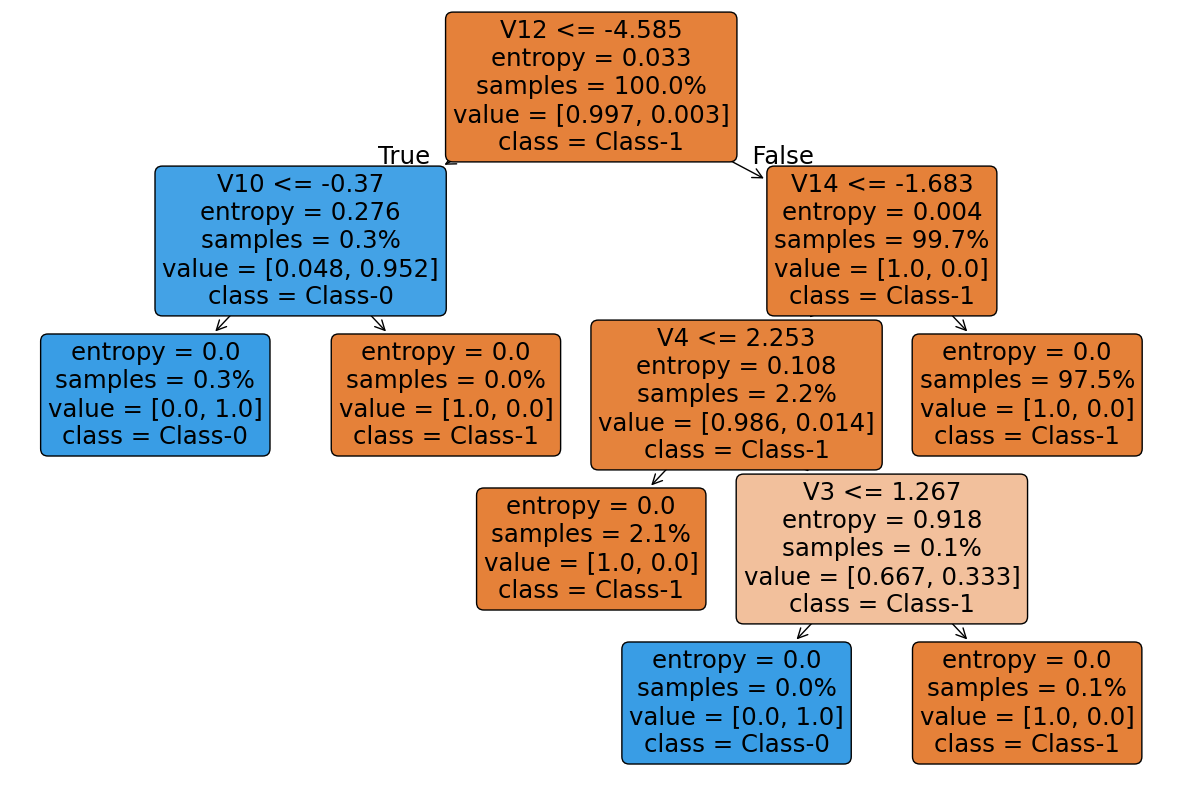

In [40]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dtree, feature_names=X.columns, class_names=['Class-1', 'Class-0'], rounded= True, # rounded node edges
               filled= True , # add colors according the the class
               proportion=True)
plt.show()